In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
import seaborn as sns

clr_palette = sns.color_palette("colorblind")

tree_clr = clr_palette[0]
ftree_clr = clr_palette[1]

In [3]:
class NodeOutCol:
    """Many not included here"""
    TS_ABS = "timestamp_absolute"
    MIN_F_TPUT = "min_flow_throughput_ratio"
    MAX_F_TPUT = "max_flow_throughput_ratio"
    AVG_F_YPU_RATIO = "avg_flow_throughput_ratio"
    TOT_TPUT_RATIO = "node_throughput_ratio"
    CURR_PWR_USE = "power_draw_watts"
    EN_USE = "energy_consumed_joule"

In [4]:
class NetOutCol:
    """Many not included here"""
    TS_ABS = "timestamp_absolute"
    NUM_FLOWS = "flows"
    AVG_TPUT_RATIO = "avg_throughput_ratio"
    TOT_TPUT_RATIO = "tot_tput_ratio"
    TOT_TPUT = "tot_tput_mbps"
    WORST_TPUT_RATIO = "worst_tput_ratio"
    CURR_PWR_USE = "power_draw_watt"
    EN_USE = "energy_consumed_joule"

In [5]:
ftree_net_df: pd.DataFrame = pd.read_parquet("../fat_tree_250x10_n=6_50hosts/raw-output/0/seed=0/networking/network.parquet")
ftree_node_df: pd.DataFrame = pd.read_parquet("../fat_tree_250x10_n=6_50hosts/raw-output/0/seed=0/networking/node.parquet")

tree_net_df: pd.DataFrame = pd.read_parquet("../tree_250x10_n=7_50hosts/raw-output/0/seed=0/networking/network.parquet")
tree_node_df: pd.DataFrame = pd.read_parquet("../tree_250x10_n=7_50hosts/raw-output/0/seed=0/networking/node.parquet")

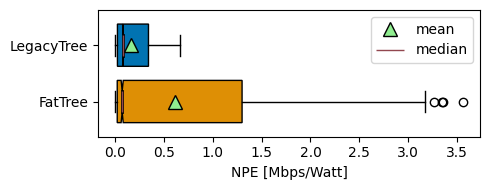

In [12]:
import math

def npe_box():
    plt.figure(figsize=(5,2))

    ftree_npe = (ftree_net_df[NetOutCol.TOT_TPUT] / ftree_net_df[NetOutCol.CURR_PWR_USE]).tolist()
    tree_npe = (tree_net_df[NetOutCol.TOT_TPUT] / tree_net_df[NetOutCol.CURR_PWR_USE]).tolist()

    ftree_npe = [0 if math.isnan(x) else x for x in ftree_npe]
    tree_npe = [0 if math.isnan(x) else x for x in tree_npe]

    bp = plt.boxplot(
        [ftree_npe, tree_npe], 
        vert=False, 
        widths=0.6, 
        positions=[0.6, 1.4], 
        patch_artist=True, 
        notch=True, 
        showmeans=True,
        meanprops={'markerfacecolor': "lightgreen", 'markeredgecolor': "black", 'markersize': 10},
        # medianprops=dict(color='#92474F', linewidth=2, linestyle='-', markeredgecolor='black')
    )

    plt.xlabel("NPE [Mbps/Watt]")
    bp["boxes"][0].set_facecolor(ftree_clr)
    bp["boxes"][1].set_facecolor(tree_clr)
    for median in bp["medians"]:
        x, y = median.get_xdata(), median.get_ydata()
        median.set_color("#92474F")
        plt.plot(x, y, color="black", linewidth=4, zorder=1)  # border layer
        plt.plot(x, y, color="black", linewidth=2, zorder=2)  # median line

    plt.yticks([0.6, 1.4], ["FatTree", "LegacyTree"])
    plt.tight_layout()
    
    plt.legend([bp['means'][0], bp["medians"][0]], ['mean', 'median'], loc ="best")
    plt.savefig("./npe_box.png", dpi=300, bbox_inches="tight")
 
npe_box()   

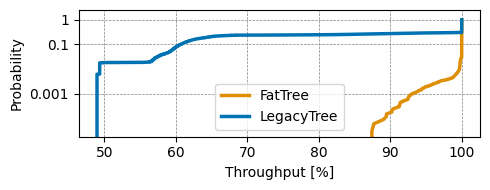

In [36]:
import matplotlib.ticker as ticker
import numpy as np

# Create avg tput plot
def tput_tail_dist():
    plt.figure(figsize=(5,2))
    def compute_rcdf(data):
        """Compute RCDF from raw data."""
        sorted_data = np.sort(data)[::-1]  # Sort the data
        cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Compute CDF
        rcdf = 1 - cdf  # Compute RCDF
        return sorted_data, rcdf

    tput1 = list(map(lambda x: x * 100, ftree_net_df[NetOutCol.AVG_TPUT_RATIO]))
    tput2 = list(map(lambda x: x * 100, tree_net_df[NetOutCol.AVG_TPUT_RATIO]))
    x1, y1 = compute_rcdf(tput1)
    x2, y2 = compute_rcdf(tput2)
    
    plt.plot(x1, y1, label="FatTree", linewidth=2.5, color=ftree_clr)
    plt.plot(x2, y2, label="LegacyTree", linewidth=2.5, color=tree_clr)
    plt.yscale("log")

    def format_func(value, tick_position):
        return f'{value:.3f}'.rstrip('0').rstrip('.') if value != 0 else '0'
    
    # Apply the custom formatter to y-axis
    plt.yticks([0.001, 0.1, 1])
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    
    plt.legend(loc="best")
    plt.xlabel("Throughput [%]")
    plt.ylabel("Probability")
    plt.ylim([None, 2.5])

    plt.grid(True, which='major', axis='both', linestyle='--', linewidth=0.5, color='gray')
    plt.tight_layout()
    
    plt.savefig("./tput_tail.png", dpi=300, bbox_inches="tight")
    

    
tput_tail_dist()